In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np



/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

def entropy(array):
    _, counts = np.unique(array, return_counts=True)
    probabilities = counts / len(array)
    shannon_entropy = -np.sum(probabilities * np.log2(probabilities))
    
    return shannon_entropy

In [3]:
pre_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PSI/ROTAMERS/preLC3B_OPLS_psi_rotamers_all.csv", index_col=0)
pre_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/BB/PHI/ROTAMERS/preLC3B_OPLS_phi_rotamers_all.csv", index_col=0)


pre_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/preLC3B_OPLS/SC/CHI1/ROTAMERS/preLC3B_OPLS_chi1_rotamers.csv", index_col=0)


In [4]:
bnd_psi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/BB/PSI/ROTAMERS/LC3B_P62_INCLUDED_psi_rotamers_all.csv", index_col=0)
bnd_phi_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/BB/PHI/ROTAMERS/LC3B_P62_INCLUDED_phi_rotamers_all.csv", index_col=0)

bnd_chi1_rotamers_df=pd.read_csv("../../../data/dihedrals/net_communication/LC3B_P62_INCLUDED/SC/CHI1/ROTAMERS/LC3B_P62_INCLUDED_chi1_rotamers.csv", index_col=0)


In [5]:
def num_ext(DF, angle):
    FORM_dih_sel_col=[]
    for i in DF.columns:
        j=i.split('.')[0].replace(angle,'')
        t_ls=re.findall(r'\d+', j)
        t=int(''.join(t_ls))
        FORM_dih_sel_col.append(t)
    return(FORM_dih_sel_col)

def entropy_ret(rot_dat,angle_):
    rot_dat_ent_df=pd.DataFrame()
    rot_dat_ent=[]
    for i in rot_dat.columns:

        ls=rot_dat[i].to_numpy()
        rot_dat_ent.append(entropy(ls))
    
    rot_dat_ent_df['Residues']=num_ext(rot_dat, angle_)
    rot_dat_ent_df[angle_]= rot_dat_ent   
    return rot_dat_ent_df

In [6]:
pre_psi_entropy=entropy_ret(pre_psi_rotamers_df, 'psi')
pre_phi_entropy=entropy_ret(pre_phi_rotamers_df, 'phi')


pre_chi1_entropy=entropy_ret(pre_chi1_rotamers_df, 'chi1')
# pre_chi2_entropy=entropy_ret(pre_chi2_rotamers_df, 'chi2')
# pre_chi3_entropy=entropy_ret(pre_chi3_rotamers_df, 'chi3')
# pre_chi4_entropy=entropy_ret(pre_chi4_rotamers_df, 'chi4')


pre_entropy_merger1=pd.merge(pre_psi_entropy, pre_phi_entropy, on='Residues', how='outer')
pre_entropy_merger2=pd.merge(pre_entropy_merger1, pre_chi1_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi2_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi3_entropy, on='Residues', how='outer')
# pre_entropy_merger2=pd.merge(pre_entropy_merger2, pre_chi4_entropy, on='Residues', how='outer')

pre_entropy_merger2=pre_entropy_merger2.fillna(0)
pre_entropy_merger2

,Residues,psi,phi,chi1
0,1,0.242109,0.994710,1.062783
1,2,0.964763,-0.000000,0.215513
2,3,0.904758,0.386450,1.463197
3,4,0.797402,0.014644,0.677710
4,5,0.621834,0.097914,1.457166
...,...,...,...,...
120,121,0.631530,0.531883,1.151683
121,122,0.981568,0.004327,1.551311
122,123,0.576848,0.004327,1.168260
123,124,0.993309,0.243634,1.193351


In [7]:
bnd_psi_entropy=entropy_ret(bnd_psi_rotamers_df, 'psi')
bnd_phi_entropy=entropy_ret(bnd_phi_rotamers_df, 'phi')


bnd_chi1_entropy=entropy_ret(bnd_chi1_rotamers_df, 'chi1')
# bnd_chi2_entropy=entropy_ret(bnd_chi2_rotamers_df, 'chi2')
# bnd_chi3_entropy=entropy_ret(bnd_chi3_rotamers_df, 'chi3')
# bnd_chi4_entropy=entropy_ret(bnd_chi4_rotamers_df, 'chi4')


bnd_entropy_merger1=pd.merge(bnd_psi_entropy, bnd_phi_entropy, on='Residues', how='outer')
bnd_entropy_merger2=pd.merge(bnd_entropy_merger1, bnd_chi1_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi2_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi3_entropy, on='Residues', how='outer')
# bnd_entropy_merger2=pd.merge(bnd_entropy_merger2, bnd_chi4_entropy, on='Residues', how='outer')

bnd_entropy_merger2=bnd_entropy_merger2.fillna(0)
bnd_entropy_merger2 # NOTE: residues 120 to 126 are the p62 LIR residues 338 to 344

,Residues,psi,phi,chi1
0,1,0.961010,0.987483,1.135048
1,2,0.371848,-0.000000,0.735954
2,3,0.528058,0.771163,1.480312
3,4,0.400723,0.145053,0.766891
4,5,0.716838,0.011398,0.684566
...,...,...,...,...
121,122,0.488430,0.271862,-0.000000
122,123,0.369381,0.004327,1.160685
123,124,0.175519,-0.000000,1.029594
124,125,0.554334,-0.000000,1.028265


In [12]:
def net_ent_calc(state_df):
    net_entropy_norm_state=[]
    for a,i,j,k in zip(state_df['Residues'],
                    state_df['psi'],
                    state_df['phi'],
                    state_df['chi1']):

        ent_ls=[i,j,k]
    
        val=sum(ent_ls)
        if val ==0:
            net_entropy_norm_state.append(0)
        else:
            net_entropy_norm_state.append(val/max(ent_ls))

    return net_entropy_norm_state

In [13]:
pre_entropy_merger2['NET_ENTROPY']=net_ent_calc(pre_entropy_merger2)
bnd_entropy_merger2['NET_ENTROPY']=net_ent_calc(bnd_entropy_merger2)

In [14]:
#d entropy = BND ENTROPY - PRE ENTROPY
d_ent_pre_bnd=[]
for pre_res, pre_ent,\
bnd_res, bnd_ent in zip(pre_entropy_merger2.iloc[:119]['Residues'],
                        pre_entropy_merger2.iloc[:119]['NET_ENTROPY'],
                       bnd_entropy_merger2.iloc[:119]['Residues'],
                       bnd_entropy_merger2.iloc[:119]['NET_ENTROPY']): # comparing residues 1-119 of LC3B
    if pre_res!=bnd_res:
        print('WARNING!')
        break
    else:
        d_ent_pre_bnd.append(bnd_ent-pre_ent)

In [15]:
min(d_ent_pre_bnd), max(d_ent_pre_bnd)

(-1.460410537537052, 1.052397941261588)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_96015/2733207688.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


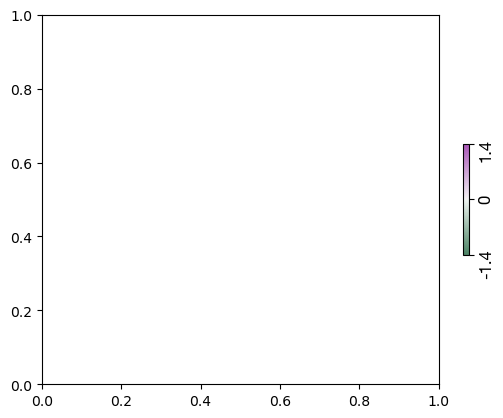

In [17]:

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }
import matplotlib.cm as cm
import matplotlib.colors as colors
from pypalettes import load_cmap


mini=-1.4
maxi=1.4


cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True)
cmp=cmap
norm = colors.Normalize(vmin=mini, vmax=maxi)



f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticks([-1.4, 0, 1.4],[-1.4, 0, 1.4],
                  rotation=90,fontdict=font)

# plt.savefig('shannon_entropy/d_SE_cbar.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

In [19]:
col_ls_all=[]

for i,j in zip([i for i in range(1,120)],d_ent_pre_bnd):
    col=f2rgb2.to_rgba(j)[:3]
    col_ls_all.append(col)
    


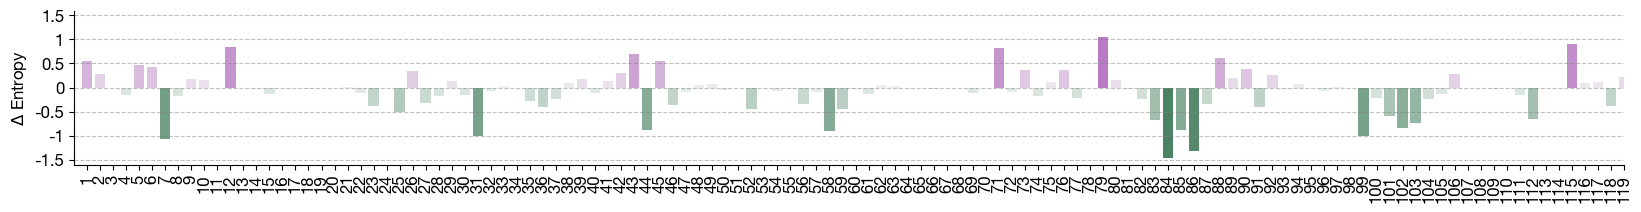

In [20]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }



fig, ax = plt.subplots(figsize=(20,2))
ax.bar([i for i in range (1,120)],
         d_ent_pre_bnd,color=col_ls_all)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
ax.set_xlim(0,15)

ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5],
             [-1.5,-1,-0.5,0,0.5,1,1.5],fontdict=font)

ax.set_xticks([res_ for res_ in [i for i in range (1,120)]],
              [str(res_) for res_ in [i for i in range (1,120)]]
              ,fontdict=font, 
             rotation=90)
ax.set_ylabel('$\Delta$ Entropy', fontdict=font)
ax.set_ylim(-1.6, 1.6)

ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.5)
# ax.xaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)
ax.yaxis.grid(which = 'minor',linestyle='dashed',alpha=0.5)


plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_SE_pre_bnd_BB_CHI1_considered.png',
           dpi=450, transparent=True,
           bbox_inches='tight')

In [21]:
MEM_RES=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]

In [22]:
def region_ord_returner(ord_data, region_ls):
    shift_ls=[]
    for i in region_ls:
        shift_val=ord_data[i-1]
        shift_ls.append(shift_val)
    return shift_ls

In [24]:
pre_ent_mtm=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), MEM_RES)
pre_ent_bp=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), pock_res)
pre_ent_rest=region_ord_returner(pre_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), rest_res)

In [25]:
bnd_ent_mtm=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), MEM_RES)
bnd_ent_bp=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), pock_res)
bnd_ent_rest=region_ord_returner(bnd_entropy_merger2.iloc[:119]['NET_ENTROPY'].to_list(), rest_res)

In [26]:
ord_region_wise=pd.DataFrame()
ord_region_wise['Region']=['MTM' for i in pre_ent_mtm]+['BP' for i in pre_ent_bp]+['REST' for i in pre_ent_rest]
ord_region_wise['pre_ord']=pre_ent_mtm+ pre_ent_bp+ pre_ent_rest
ord_region_wise['bnd_ord']=bnd_ent_mtm+ bnd_ent_bp+ bnd_ent_rest
ord_region_wise

,Region,pre_ord,bnd_ord
0,MTM,2.163755,2.716663
1,MTM,1.223384,1.505260
2,MTM,1.882457,1.877667
3,MTM,1.868262,1.711672
4,MTM,1.493937,1.970881
...,...,...,...
114,REST,1.014772,1.005508
115,REST,1.098435,1.994838
116,REST,1.502937,1.591231
117,REST,1.882572,1.999724


/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_96015/770565282.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='pre_ord', data=ord_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. P

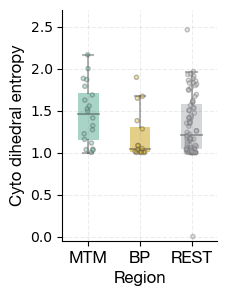

In [126]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]


sns.boxplot(x='Region', y='pre_ord', data=ord_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='pre_ord', data=ord_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('Cyto dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)



plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_region_wise_pre.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_96015/1305770364.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='bnd_ord', data=ord_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

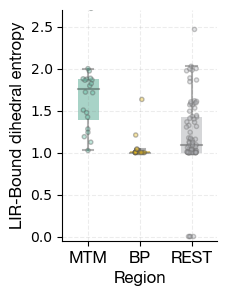

In [125]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]


sns.boxplot(x='Region', y='bnd_ord', data=ord_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='bnd_ord', data=ord_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('LIR-Bound dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_region_wise_bnd.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [34]:
ord_region_wise_compressed=pd.DataFrame()
ord_region_wise_compressed["Region"]=ord_region_wise["Region"].to_list()+ord_region_wise["Region"].to_list()
ord_region_wise_compressed["net_ent"]=ord_region_wise["pre_ord"].to_list()+ord_region_wise["bnd_ord"].to_list()
ord_region_wise_compressed["state"]=["Cyto" for i in ord_region_wise["pre_ord"]]+\
                                    ["LIR-BOUND" for i in ord_region_wise["bnd_ord"]]
ord_region_wise_compressed

,Region,net_ent,state
0,MTM,2.163755,Cyto
1,MTM,1.223384,Cyto
2,MTM,1.882457,Cyto
3,MTM,1.868262,Cyto
4,MTM,1.493937,Cyto
...,...,...,...
233,REST,1.005508,LIR-BOUND
234,REST,1.994838,LIR-BOUND
235,REST,1.591231,LIR-BOUND
236,REST,1.999724,LIR-BOUND


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


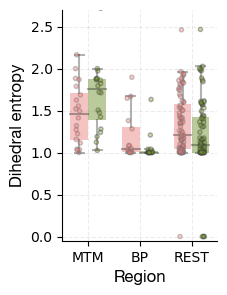

In [124]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.5},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
#col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]

col_ls=["#FF7878","#7DA629"]
box=sns.boxplot(x='Region', y='net_ent', data=ord_region_wise_compressed, hue="state",
            showfliers=False,width=0.7,palette=col_ls,
            **PROPS,ax=ax)
# sns.catplot(kind="box", x="Region", y="net_ent", hue="state", data=ord_region_wise_compressed, 
#                 dodge=True,showfliers=False,palette=col_ls,**PROPS,ax=ax)

sns.stripplot(x='Region', y='net_ent', data=ord_region_wise_compressed, hue="state",
              jitter=True, alpha=0.4, 
              dodge=True, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
# ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('Dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


box.legend_.remove()
# plt.legend()

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_regionwise_pre_bnd_BB_CHI1_considered.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_96015/133870571.py:17: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='state', y='net_ent', data=ord_region_wise_compressed,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

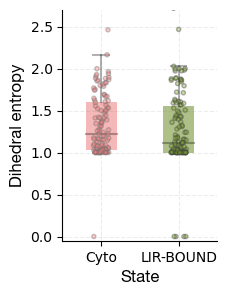

In [121]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
#col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]

col_ls=["#FF7878","#7DA629"]
box=sns.boxplot(x='state', y='net_ent', data=ord_region_wise_compressed,
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)
# sns.catplot(kind="box", x="Region", y="net_ent", hue="state", data=ord_region_wise_compressed, 
#                 dodge=True,showfliers=False,palette=col_ls,**PROPS,ax=ax)

sns.stripplot(x='state', y='net_ent', data=ord_region_wise_compressed,
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
# ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

# ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
# ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('State', fontdict=font)
ax.set_ylabel('Dihedral entropy', fontdict=font)

ax.set_ylim(-0.05,2.7)


# plt.legend()

plt.savefig('../../../plots/dihedrals/dihedral_entropy_calculations/dihedral_entropy_overall_pre_bnd_BB_CHI1_considered.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [ ]:
# overall (applying threshold)

In [100]:
pre_net_ent=ord_region_wise_compressed[ord_region_wise_compressed["state"]=="Cyto"][["net_ent"]]>=1.5
disord_resid_pre=len(pre_net_ent[pre_net_ent["net_ent"]]==True)/len(pre_net_ent)
disord_resid_pre

0.31932773109243695

In [101]:
bnd_net_ent=ord_region_wise_compressed[ord_region_wise_compressed["state"]=="LIR-BOUND"][["net_ent"]]>=1.5
disord_resid_bnd=len(bnd_net_ent[bnd_net_ent["net_ent"]]==True)/len(bnd_net_ent)
disord_resid_bnd

0.2689075630252101

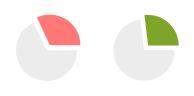

In [109]:
overall_dis=[disord_resid_pre,disord_resid_bnd]
col_ls=["#FF7878","#7DA629"]
counter=-1

fig = plt.figure(figsize=(7, 55))
for val in overall_dis:
    counter=counter+1
    y = [val, 1-val]
    y_d=y
    explode = (0.1, 0.1)

    plt.subplot(60,7,counter+1)

    plt.pie(y_d,explode=explode,colors=[col_ls[counter],'#ECECEC',])
    #plt.title(i.split('.')[0].replace('chi1',''))
    plt.tight_layout()
# legend_elements=[Line2D([0], [0], markerfacecolor='#EC7063', marker='o',color='w', label='%s'%(labels[0])),
#             Line2D([0], [0], markerfacecolor='#8E44AD', marker='o', color='w',label='%s'%(labels[1])),
#             Line2D([0], [0], markerfacecolor='#3498DB', marker='o',color='w', label='%s'%(labels[2]))]

# plt.legend(handles=legend_elements,bbox_to_anchor=(7.20, 0.05,1,10),loc='upper left',title='Fraction of Chi1 \n rotameric states ')
plt.show()

In [ ]:
# region-wise (applying threshold)

In [116]:
disord_resid_pre_reg_ls=[]
for reg_ in ["MTM","BP","REST"]:
    pre_net_ent=ord_region_wise_compressed[ord_region_wise_compressed["state"]=="Cyto"]
    pre_net_ent_reg_fil=pre_net_ent[pre_net_ent["Region"]==reg_]
    pre_net_ent_reg_fil=pre_net_ent_reg_fil[["net_ent"]]>=1.5
    disord_resid_pre_reg=len(pre_net_ent_reg_fil[pre_net_ent_reg_fil["net_ent"]]==True)/len(pre_net_ent_reg_fil)
    disord_resid_pre_reg_ls.append(disord_resid_pre_reg)
    
disord_resid_pre_reg_ls

[0.45, 0.1875, 0.3132530120481928]

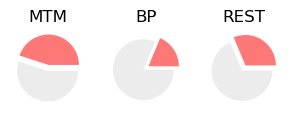

In [115]:

#col_ls=["#FF7878","#7DA629"]
title_ls=["MTM", "BP", "REST"]
counter=-1

fig = plt.figure(figsize=(7, 55))
for val in disord_resid_pre_reg_ls:
    counter=counter+1
    y = [val, 1-val]
    y_d=y
    explode = (0.1, 0.1)
    

    plt.subplot(60,7,counter+1)

    plt.pie(y_d,explode=explode,colors=["#FF7878",'#ECECEC',])
    plt.title(title_ls[counter])
    plt.tight_layout()
# legend_elements=[Line2D([0], [0], markerfacecolor='#EC7063', marker='o',color='w', label='%s'%(labels[0])),
#             Line2D([0], [0], markerfacecolor='#8E44AD', marker='o', color='w',label='%s'%(labels[1])),
#             Line2D([0], [0], markerfacecolor='#3498DB', marker='o',color='w', label='%s'%(labels[2]))]

# plt.legend(handles=legend_elements,bbox_to_anchor=(7.20, 0.05,1,10),loc='upper left',title='Fraction of Chi1 \n rotameric states ')
plt.show()

In [118]:
disord_resid_bnd_reg_ls=[]
for reg_ in ["MTM","BP","REST"]:
    bnd_net_ent=ord_region_wise_compressed[ord_region_wise_compressed["state"]=="LIR-BOUND"]
    bnd_net_ent_reg_fil=bnd_net_ent[bnd_net_ent["Region"]==reg_]
    bnd_net_ent_reg_fil=bnd_net_ent_reg_fil[["net_ent"]]>=1.5
    disord_resid_bnd_reg=len(bnd_net_ent_reg_fil[bnd_net_ent_reg_fil["net_ent"]]==True)/len(bnd_net_ent_reg_fil)
    disord_resid_bnd_reg_ls.append(disord_resid_bnd_reg)
    
disord_resid_bnd_reg_ls

[0.65, 0.0625, 0.21686746987951808]

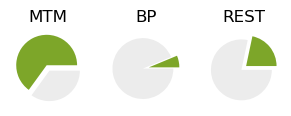

In [120]:

#col_ls=["#FF7878","#7DA629"]
title_ls=["MTM", "BP", "REST"]
counter=-1

fig = plt.figure(figsize=(7, 55))
for val in disord_resid_bnd_reg_ls:
    counter=counter+1
    y = [val, 1-val]
    y_d=y
    explode = (0.1, 0.1)
    

    plt.subplot(60,7,counter+1)

    plt.pie(y_d,explode=explode,colors=["#7DA629",'#ECECEC',])
    plt.title(title_ls[counter])
    plt.tight_layout()
# legend_elements=[Line2D([0], [0], markerfacecolor='#EC7063', marker='o',color='w', label='%s'%(labels[0])),
#             Line2D([0], [0], markerfacecolor='#8E44AD', marker='o', color='w',label='%s'%(labels[1])),
#             Line2D([0], [0], markerfacecolor='#3498DB', marker='o',color='w', label='%s'%(labels[2]))]

# plt.legend(handles=legend_elements,bbox_to_anchor=(7.20, 0.05,1,10),loc='upper left',title='Fraction of Chi1 \n rotameric states ')
plt.show()